# **Aerofit**

Aerofit is a leading brand in the field of fitness equipment. Aerofit provides a product range including machines such as treadmills, exercise bikes, gym equipment, and fitness accessories to cater to the needs of all categories of people.

## **Business Problem**

The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to the new customers. The team decides to investigate whether there are differences across the product with respect to customer characteristics.

In [50]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

### **Aerofit Dataset**

In [51]:
aerofit = pd.read_csv("https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749")

In [52]:
aerofit

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120


## **Columns description:**
- **Product Purchased:**	KP281, KP481, or KP781
- **Age:**	In years
- **Gender:**	Male/Female
- **Education:**	In years
- **MaritalStatus:**	Single or partnered
- **Usage:**	The average number of times the customer plans to use the treadmill each week.
- **Income:**	Annual income (in $)
- **Fitness:**	Self-rated fitness on a 1-to-5 scale, where 1 is the poor shape and 5 is the excellent shape.
- **Miles:**	The average number of miles the customer expects to walk/run each week

In [53]:
aerofit.shape

(180, 9)

In [54]:
aerofit.describe(include = "all")

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
count,180,180.000000,180,180.000000,180,180.000000,180.000000,180.000000,180.000000
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN
top,KP281,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN
mean,NaN,28.788889,NaN,15.572222,NaN,3.455556,3.311111,53719.577778,103.194444
std,NaN,6.943498,NaN,1.617055,NaN,1.084797,0.958869,16506.684226,51.863605
min,NaN,18.000000,NaN,12.000000,NaN,2.000000,1.000000,29562.000000,21.000000
25%,NaN,24.000000,NaN,14.000000,NaN,3.000000,3.000000,44058.750000,66.000000
50%,NaN,26.000000,NaN,16.000000,NaN,3.000000,3.000000,50596.500000,94.000000
75%,NaN,33.000000,NaN,16.000000,NaN,4.000000,4.000000,58668.000000,114.750000


In [55]:
aerofit.describe(include = [np.number])

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


- No significant outliers impacting the mean so all the means are close the median value
- Few outliers in:
  1. Income
  2. Miles

In [56]:
aerofit.describe(exclude = [np.number])

,Product,Gender,MaritalStatus
count,180,180,180
unique,3,2,2
top,KP281,Male,Partnered
freq,80,104,107


In [57]:
aerofit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [58]:
aerofit.isna().sum().sum()

0

### **Observations:**
1. There are no missing values
2. There are no significant outliers found in the dataset
3. **KP281** is the most popular product in the dataset having the maximum frequency.
4. The dataset mostly has data for Males since out of 180 entries 104 are Males and the remaining are Females.



## **Univariate Analysis**

In [59]:
# seperate dataframe only containing the categories
df_obj = aerofit.select_dtypes(include = ["object"])
df_obj

,Product,Gender,MaritalStatus
0,KP281,Male,Single
1,KP281,Male,Single
2,KP281,Female,Partnered
3,KP281,Male,Single
4,KP281,Male,Partnered
...,...,...,...
175,KP781,Male,Single
176,KP781,Male,Single
177,KP781,Male,Single
178,KP781,Male,Partnered


In [60]:
# seperate dataframe only containing the metrics
df_num = aerofit.select_dtypes(include = ["int64"])
df_num

,Age,Education,Usage,Fitness,Income,Miles
0,18,14,3,4,29562,112
1,19,15,2,3,31836,75
2,19,14,4,3,30699,66
3,19,12,3,3,32973,85
4,20,13,4,2,35247,47
...,...,...,...,...,...,...
175,40,21,6,5,83416,200
176,42,18,5,4,89641,200
177,45,16,5,5,90886,160
178,47,18,4,5,104581,120


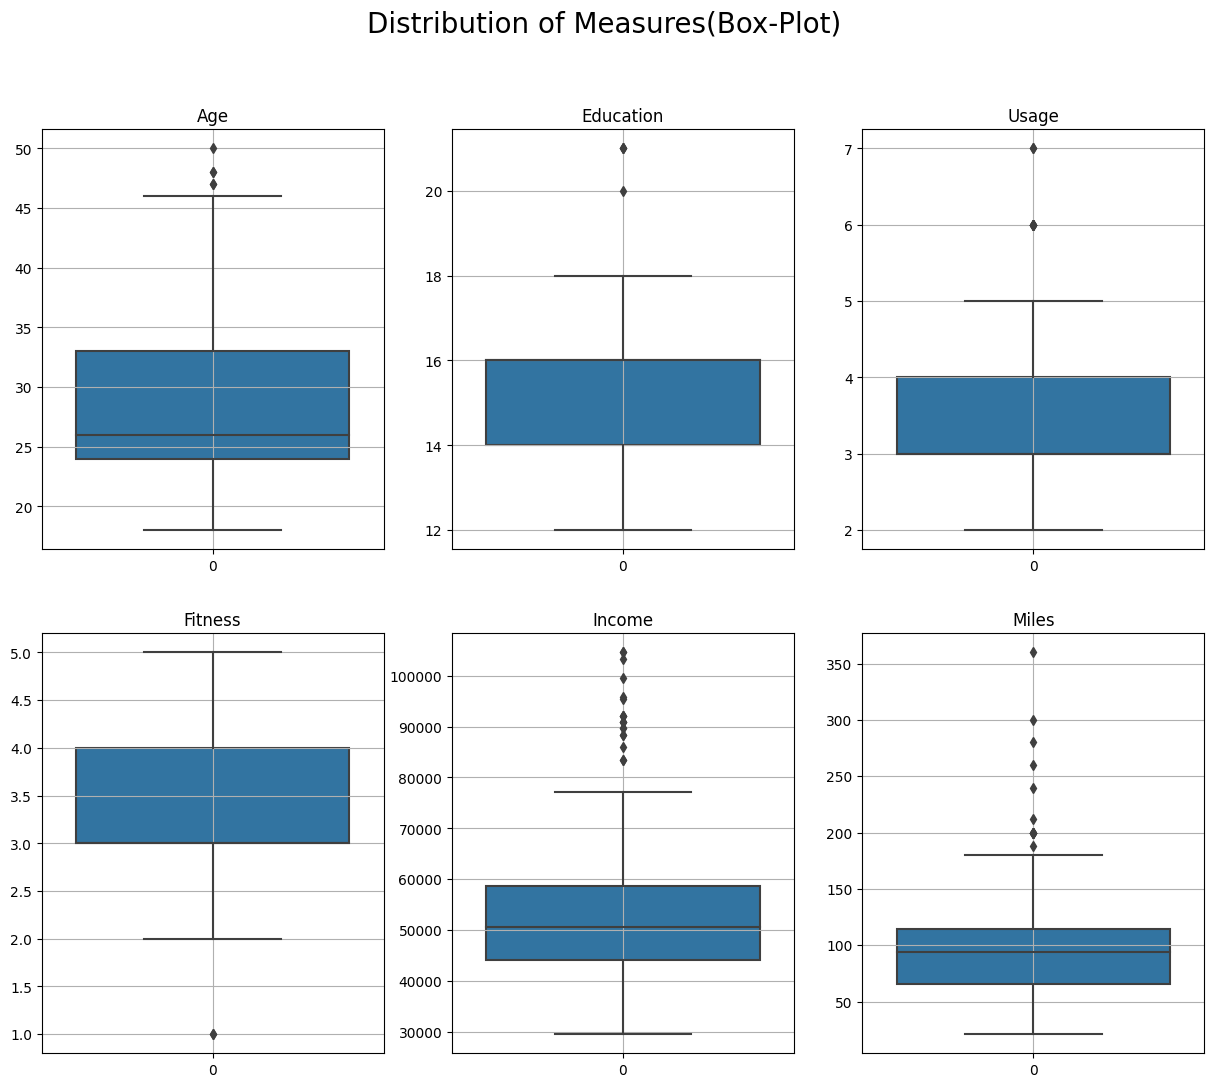

In [61]:
fig = plt.figure(figsize=(15,12))
fig.suptitle("Distribution of Measures(Box-Plot)", fontsize=20)

plt.subplot(2,3,1)

sns.boxplot(aerofit["Age"], orient='v')
plt.title("Age", fontsize = 12)
plt.grid()

plt.subplot(2,3,2)

sns.boxplot(aerofit["Education"], orient='v')
plt.title("Education", fontsize = 12)
plt.grid()

plt.subplot(2,3,3)

sns.boxplot(aerofit["Usage"], orient='v')
plt.title("Usage", fontsize = 12)
plt.grid()

plt.subplot(2,3,4)

sns.boxplot(aerofit["Fitness"], orient='v')
plt.title("Fitness", fontsize = 12)
plt.grid()

plt.subplot(2,3,5)

sns.boxplot(aerofit["Income"], orient='v')
plt.title("Income", fontsize = 12)
plt.grid()

plt.subplot(2,3,6)

sns.boxplot(aerofit["Miles"], orient='v')
plt.title("Miles", fontsize = 12)
plt.grid()



plt.show()

## **Observations:**
1. Age, Education and Usage have **few outliers**
2. Income, Miles have **more outliers**
3. But none of the outliers are too extreme to have a significant impact on their means since they are relatively closer to their median.

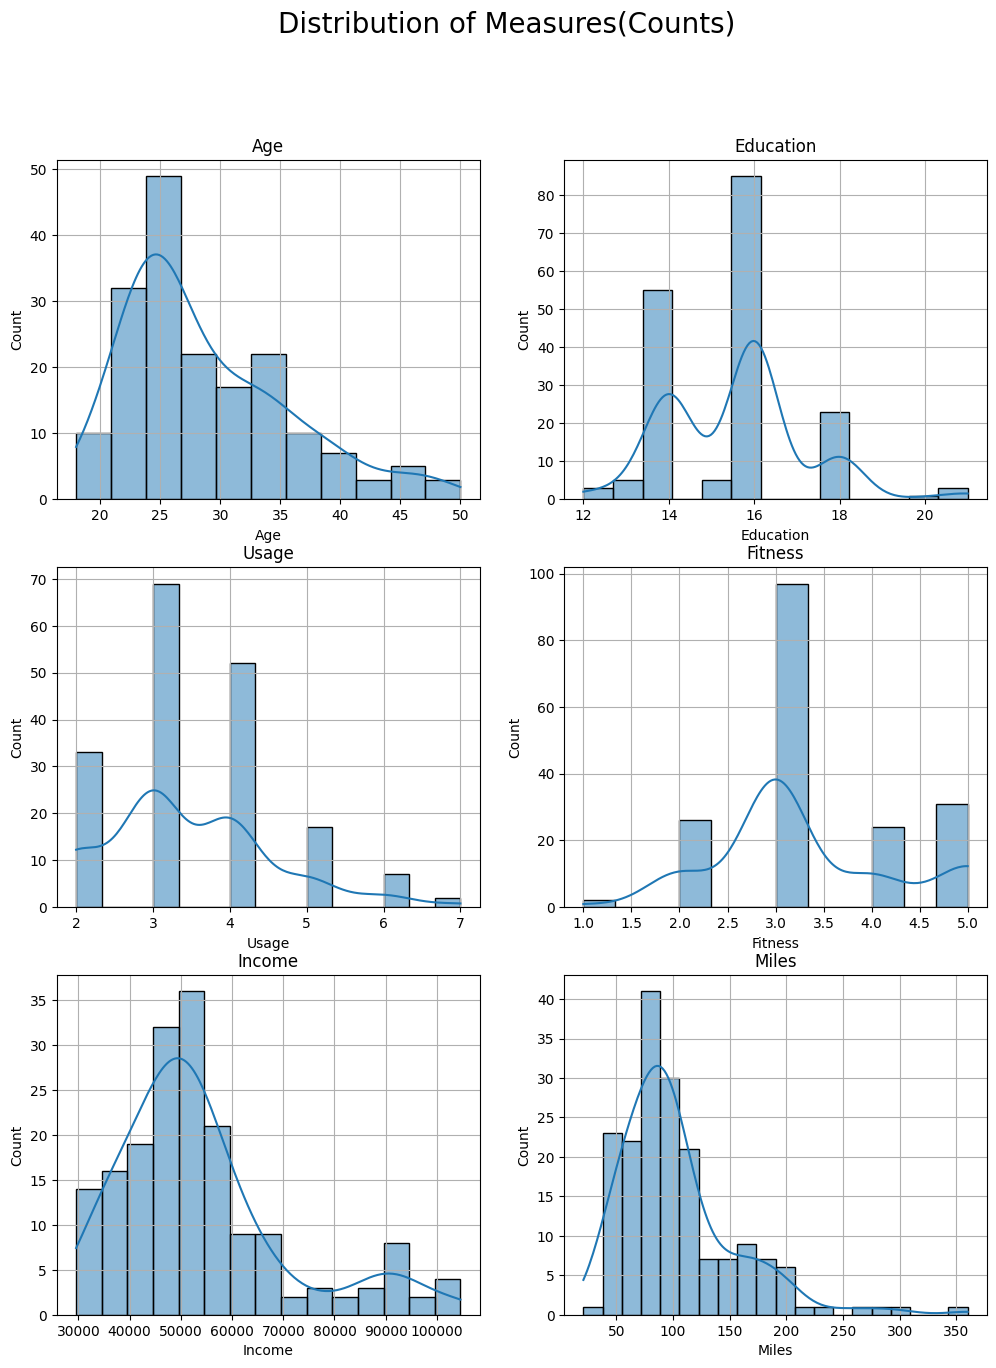

In [62]:
fig = plt.figure(figsize=(12,15))
fig.suptitle("Distribution of Measures(Counts)", fontsize=20)

plt.subplot(3,2,1)

sns.histplot(aerofit["Age"], kde = True)
plt.title("Age", fontsize = 12)
plt.grid()

plt.subplot(3,2,2)

sns.histplot(aerofit["Education"], kde = True)
plt.title("Education", fontsize = 12)
plt.grid()

plt.subplot(3,2,3)

sns.histplot(aerofit["Usage"], kde = True)
plt.title("Usage", fontsize = 12)
plt.grid()

plt.subplot(3,2,4)

sns.histplot(aerofit["Fitness"], kde = True)
plt.title("Fitness", fontsize = 12)
plt.grid()

plt.subplot(3,2,5)

sns.histplot(aerofit["Income"], kde = True)
plt.title("Income", fontsize = 12)
plt.grid()

plt.subplot(3,2,6)

sns.histplot(aerofit["Miles"], kde = True)
plt.title("Miles", fontsize = 12)
plt.grid()



plt.show()

In [63]:
df_obj.head()

,Product,Gender,MaritalStatus
0,KP281,Male,Single
1,KP281,Male,Single
2,KP281,Female,Partnered
3,KP281,Male,Single
4,KP281,Male,Partnered


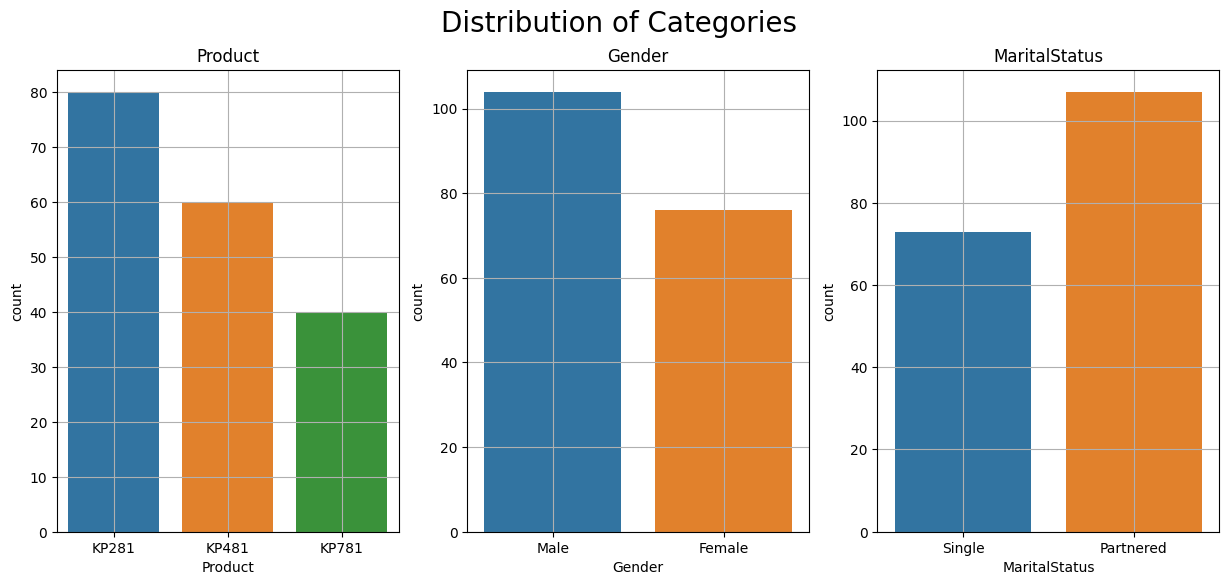

In [64]:
fig = plt.figure(figsize=(15,6))
fig.suptitle("Distribution of Categories", fontsize = 20)

plt.subplot(1,3,1)

sns.countplot(data = aerofit, x = 'Product')
plt.title("Product", fontsize = 12)
plt.grid()

plt.subplot(1,3,2)

sns.countplot(data = aerofit, x = 'Gender')
plt.title("Gender", fontsize = 12)
plt.grid()

plt.subplot(1,3,3)

sns.countplot(data = aerofit, x = 'MaritalStatus')
plt.title("MaritalStatus", fontsize = 12)
plt.grid()

## **Observations:**
1. Most popular categories:
  - Product: KP281
  - Gender: Male
  - Marital Status: Partnered

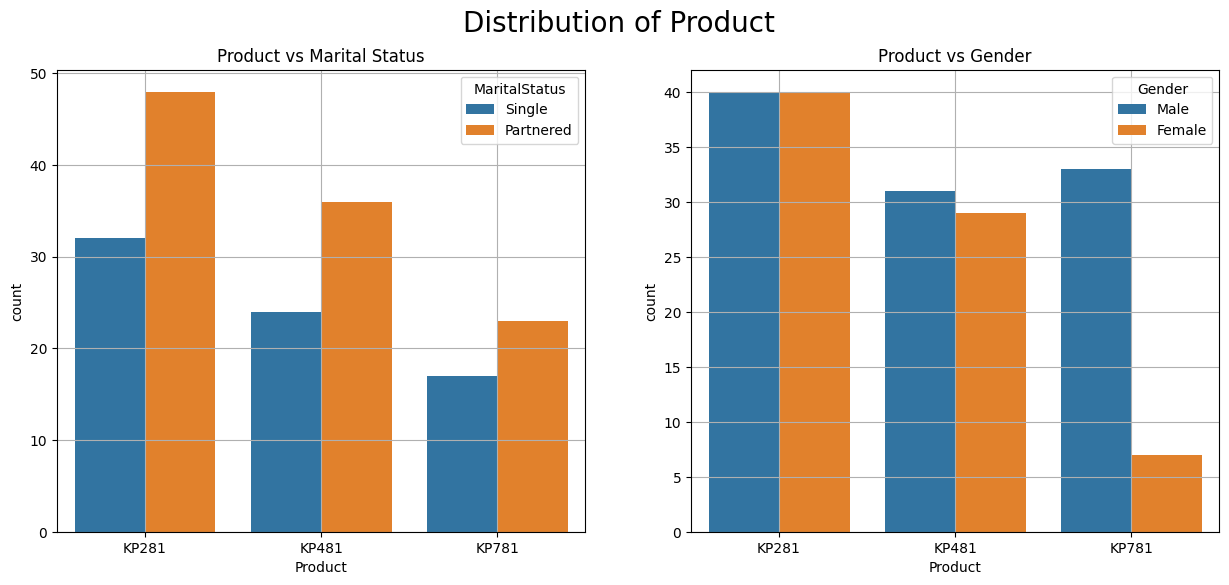

In [65]:
fig = plt.figure(figsize=(15,6))
fig.suptitle("Distribution of Product", fontsize = 20)

plt.subplot(1,2,1)

sns.countplot(data = aerofit, x = 'Product', hue = 'MaritalStatus')
plt.title("Product vs Marital Status", fontsize = 12)
plt.grid()

plt.subplot(1,2,2)

sns.countplot(data = aerofit, x = 'Product', hue = 'Gender')
plt.title("Product vs Gender", fontsize = 12)
plt.grid()

## **Observations:**
**Product vs Marital Status**
1. Partnered individuals or couples have greater demand for products than Singles.
2. Demand for KP281 amongst Partnered individuals is more than the other KP481 and KP781 maybe because they are the cheapest.
3. **Product preference in descending order across Marital Status:**
  - KP281
  - KP481
  - KP781

**Product vs Gender**
1. Demand for KP281 across genders is almost equal.
2. **KP781** although the most expensive product is in **more demand by Males**
3. **KP781** is the least preffered product by **Females**.
4. **Male users product preference in descending order:**
  - KP281
  - KP781
  - KP481
5. **Female users product preference in descending order:**
  - KP281
  - KP481
  - KP781

## More in-depth analysis for the likelihood of the product for Gender and Marital Status will be done in the **Probability analysis** section


#**Bivariate Analysis**

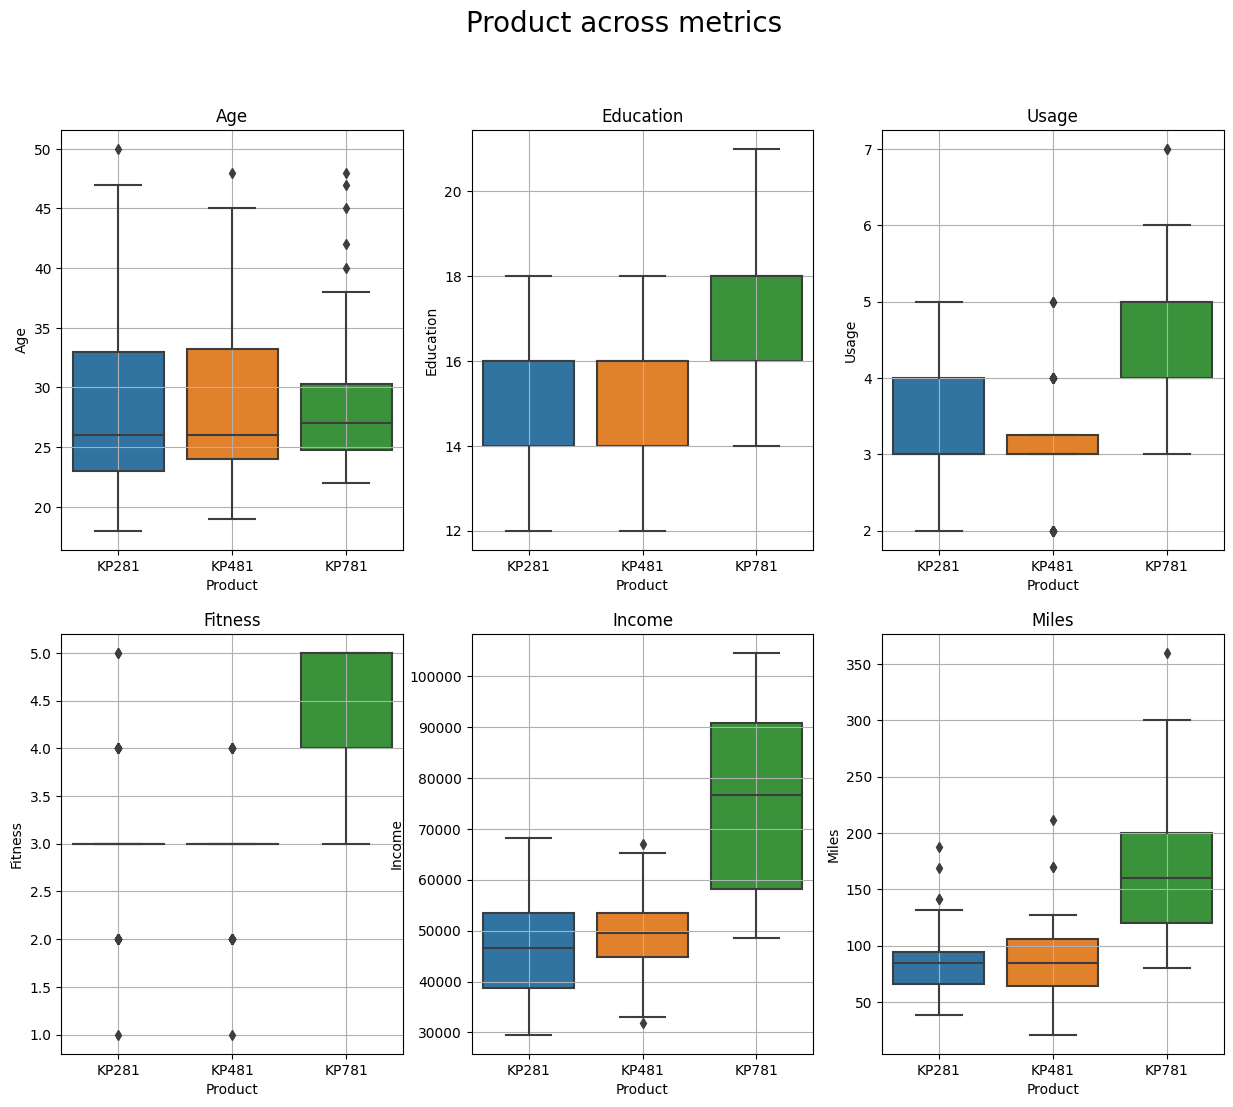

In [66]:
fig = plt.figure(figsize=(15,12))
fig.suptitle("Product across metrics", fontsize = 20)

plt.subplot(2,3,1)

sns.boxplot(y = aerofit["Age"], x = aerofit["Product"])
plt.title("Age", fontsize = 12)
plt.grid()

plt.subplot(2,3,2)

sns.boxplot(y = aerofit["Education"], x = aerofit["Product"])
plt.title("Education", fontsize = 12)
plt.grid()

plt.subplot(2,3,3)

sns.boxplot(y = aerofit["Usage"], x = aerofit["Product"])
plt.title("Usage", fontsize = 12)
plt.grid()

plt.subplot(2,3,4)

sns.boxplot(y = aerofit["Fitness"], x = aerofit["Product"])
plt.title("Fitness", fontsize = 12)
plt.grid()

plt.subplot(2,3,5)

sns.boxplot(y = aerofit["Income"], x = aerofit["Product"])
plt.title("Income", fontsize = 12)
plt.grid()

plt.subplot(2,3,6)

sns.boxplot(y = aerofit["Miles"], x = aerofit["Product"])
plt.title("Miles", fontsize = 12)
plt.grid()



plt.show()

## **Observations:**
1. **Product KP781** is in demand for users having **relatively higher Education, Usage, Fitness, Income and Miles traveled.**
2. **Product KP781** is mostly in demand for **users in mid 20s to early 30s** since the most of users have ages between 25 - 30
3. Product KP281 and KP481 has almost equal ranges across all measures except:
  - KP481 has the least usage per week than most of the products


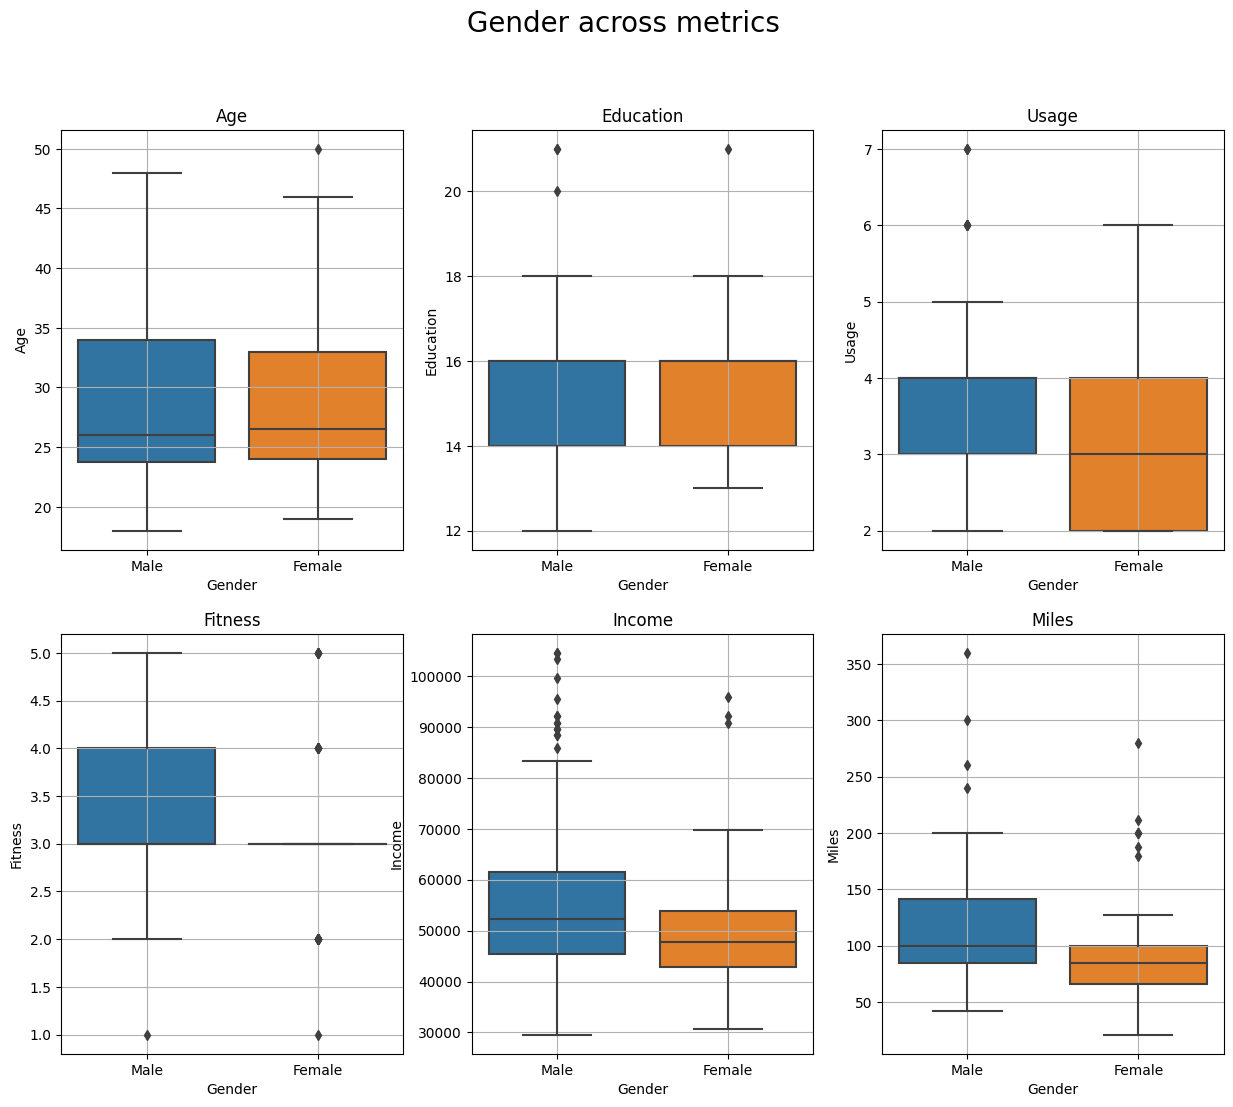

In [67]:
fig = plt.figure(figsize=(15,12))
fig.suptitle("Gender across metrics", fontsize = 20)

plt.subplot(2,3,1)

sns.boxplot(y = aerofit["Age"], x = aerofit["Gender"])
plt.title("Age", fontsize = 12)
plt.grid()

plt.subplot(2,3,2)

sns.boxplot(y = aerofit["Education"], x = aerofit["Gender"])
plt.title("Education", fontsize = 12)
plt.grid()

plt.subplot(2,3,3)

sns.boxplot(y = aerofit["Usage"], x = aerofit["Gender"])
plt.title("Usage", fontsize = 12)
plt.grid()

plt.subplot(2,3,4)

sns.boxplot(y = aerofit["Fitness"], x = aerofit["Gender"])
plt.title("Fitness", fontsize = 12)
plt.grid()

plt.subplot(2,3,5)

sns.boxplot(y = aerofit["Income"], x = aerofit["Gender"])
plt.title("Income", fontsize = 12)
plt.grid()

plt.subplot(2,3,6)

sns.boxplot(y = aerofit["Miles"], x = aerofit["Gender"])
plt.title("Miles", fontsize = 12)
plt.grid()



plt.show()

## **Observations**
1. Most Males have higher income than Females (from the chart above)
2. Most Males run greater miles than Females

But does that have any impact on the demand for the products?


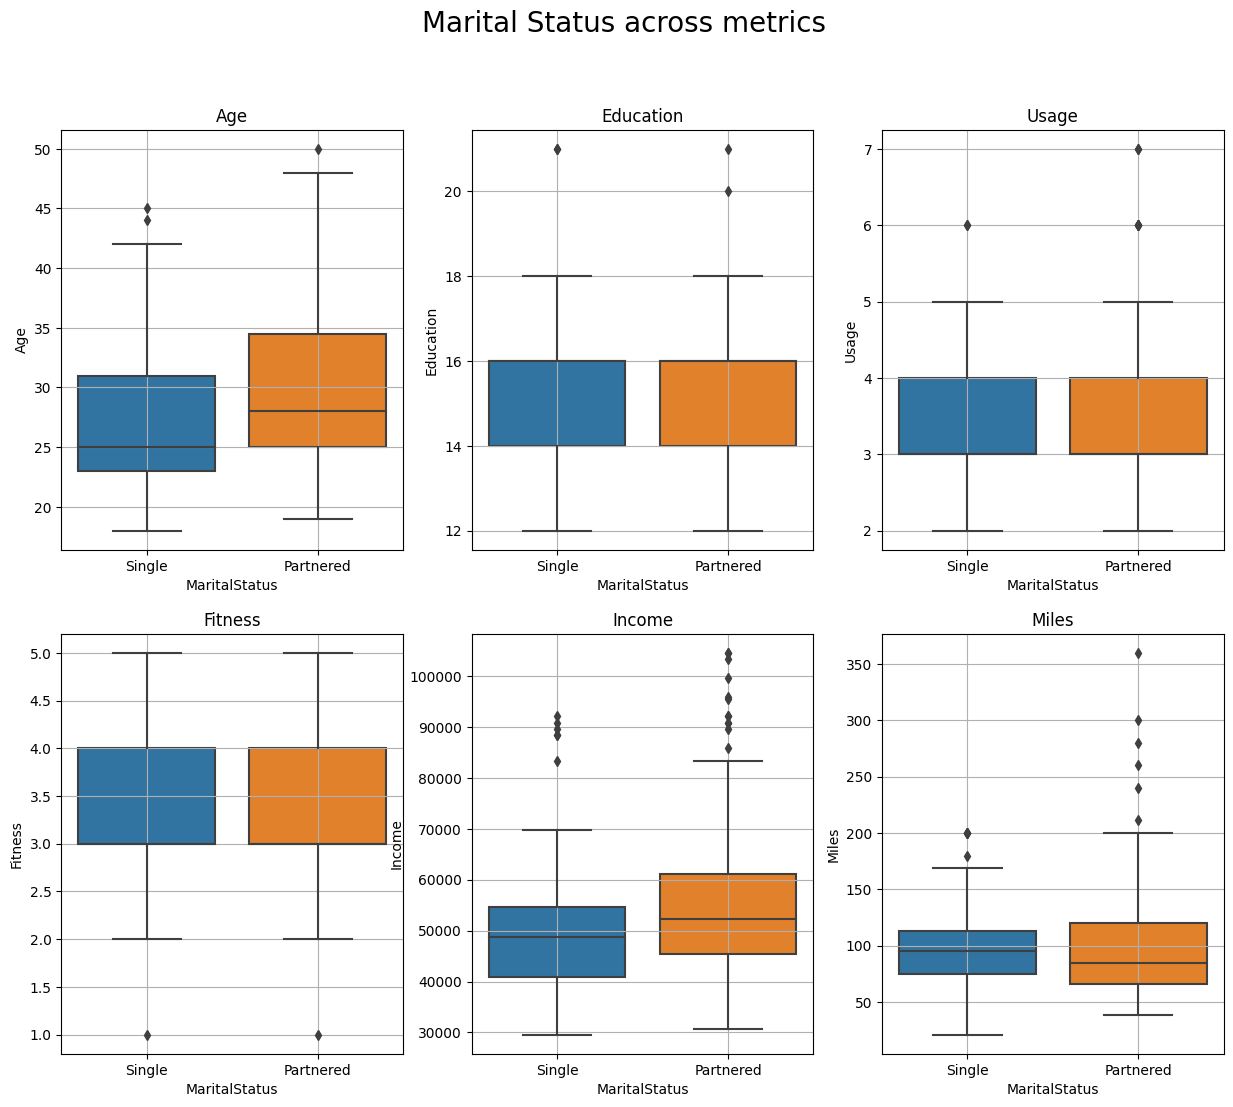

In [68]:
fig = plt.figure(figsize=(15,12))
fig.suptitle("Marital Status across metrics", fontsize = 20)

plt.subplot(2,3,1)

sns.boxplot(y = aerofit["Age"], x = aerofit["MaritalStatus"])
plt.title("Age", fontsize = 12)
plt.grid()

plt.subplot(2,3,2)

sns.boxplot(y = aerofit["Education"], x = aerofit["MaritalStatus"])
plt.title("Education", fontsize = 12)
plt.grid()

plt.subplot(2,3,3)

sns.boxplot(y = aerofit["Usage"], x = aerofit["MaritalStatus"])
plt.title("Usage", fontsize = 12)
plt.grid()

plt.subplot(2,3,4)

sns.boxplot(y = aerofit["Fitness"], x = aerofit["MaritalStatus"])
plt.title("Fitness", fontsize = 12)
plt.grid()

plt.subplot(2,3,5)

sns.boxplot(y = aerofit["Income"], x = aerofit["MaritalStatus"])
plt.title("Income", fontsize = 12)
plt.grid()

plt.subplot(2,3,6)

sns.boxplot(y = aerofit["Miles"], x = aerofit["MaritalStatus"])
plt.title("Miles", fontsize = 12)
plt.grid()


plt.show()

## **Observations**
1. Most Partnered users have higher income than Single users (from the chart above)

But does that effect the choice of the products for these users?

## **Multivariate Analysis**

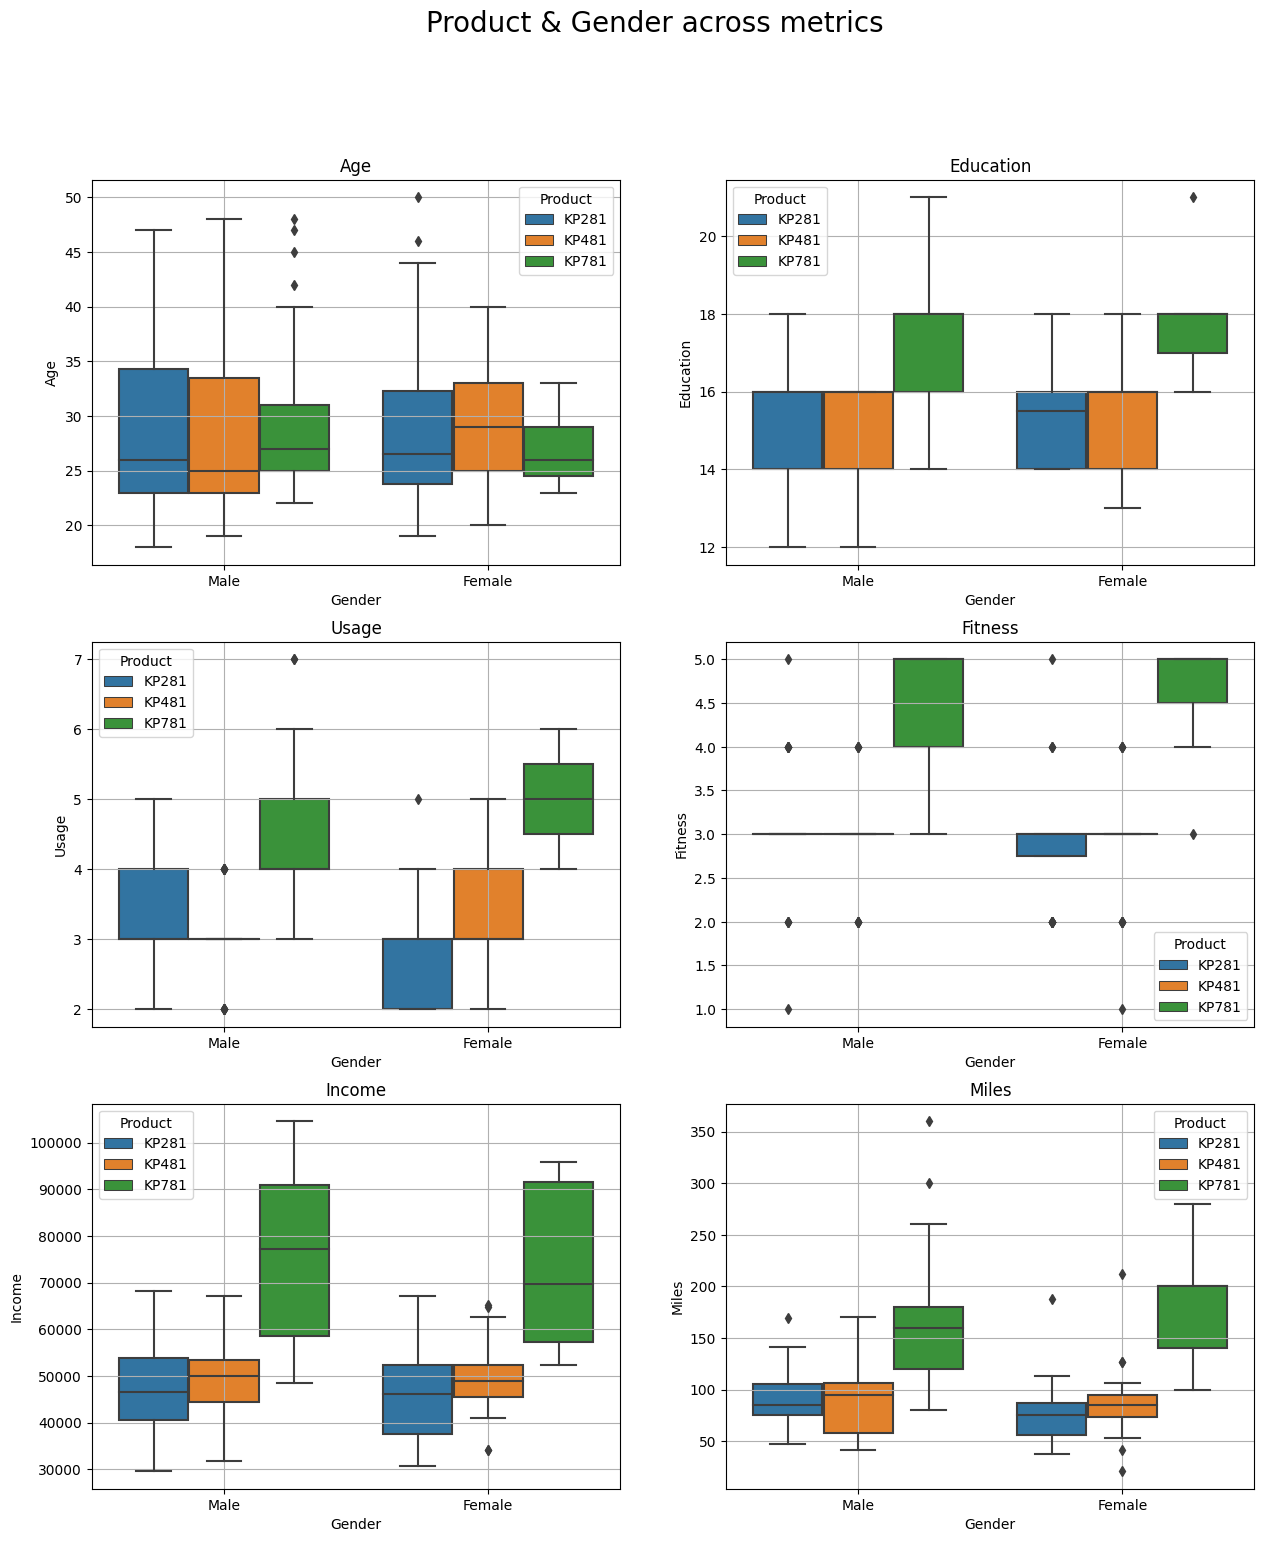

In [69]:
fig = plt.figure(figsize=(15,17))
fig.suptitle("Product & Gender across metrics", fontsize = 20)



plt.subplot(3,2,1)

sns.boxplot(data = aerofit, y = "Age", x = "Gender", hue = "Product")
plt.title("Age", fontsize = 12)
plt.grid()

plt.subplot(3,2,2)

sns.boxplot(data = aerofit, y = "Education", x = "Gender", hue = "Product")
plt.title("Education", fontsize = 12)
plt.grid()

plt.subplot(3,2,3)

sns.boxplot(data = aerofit, y = "Usage", x = "Gender", hue = "Product")
plt.title("Usage", fontsize = 12)
plt.grid()

plt.subplot(3,2,4)

sns.boxplot(data = aerofit, y = "Fitness", x = "Gender", hue = "Product")
plt.title("Fitness", fontsize = 12)
plt.grid()

plt.subplot(3,2,5)

sns.boxplot(data = aerofit, y = "Income", x = "Gender", hue = "Product")
plt.title("Income", fontsize = 12)
plt.grid()

plt.subplot(3,2,6)

sns.boxplot(data = aerofit, y = "Miles", x = "Gender", hue = "Product")
plt.title("Miles", fontsize = 12)
plt.grid()




plt.show()

## **Observations:**
1. **Product KP281:**
  - preffered by younger Females as 75 % of them have less than 33 years of age.
  - Males having less years of Education (12 as per the data) are also seen to be using the product.
  - Females with a generally low usage about 2 to 3 times a week prefer it.
  - In demand for users with income between 30000 to 69000 irrespective of genders
  - preffered by Males with a comparatively higher miles runned (about 110 miles) compared to females
2. **Product KP481:**
  - Male users have similar age range compared to Product KP281
  - Preferred by comparatively younger female users then KP281 because of less spread of data at the top and no outliers.
  - The range for education and usage is quite similar to both genders compared to KP281
  - Users have similar Income ranges compared to KP281, although for females the min income level(excluding outliers) is seen to be 40000 compared to 31000 for KP281
  - Females with greater miles walked prefer KP481
3. **Product KP781:**
    - Mostly preffered by younger females than males
    - Few females with lower years of education compared to Males can also be seen to be able to opertate KP781
    - Females looking out for greater usage than Males prefer KP781.
    - Although both the genders having a higher income (59000 - 61000) prefer KP781, the spread for females in much less compared to Males.
    - 75% of the Females having income <= 53000 do not buy KP781 but would rather buy KP281 OR KP481
    - Few from the 75% of Males having income <= 53000 may buy KP781.
    - Female users expecting to walk greater miles prefer KP781 than Males.

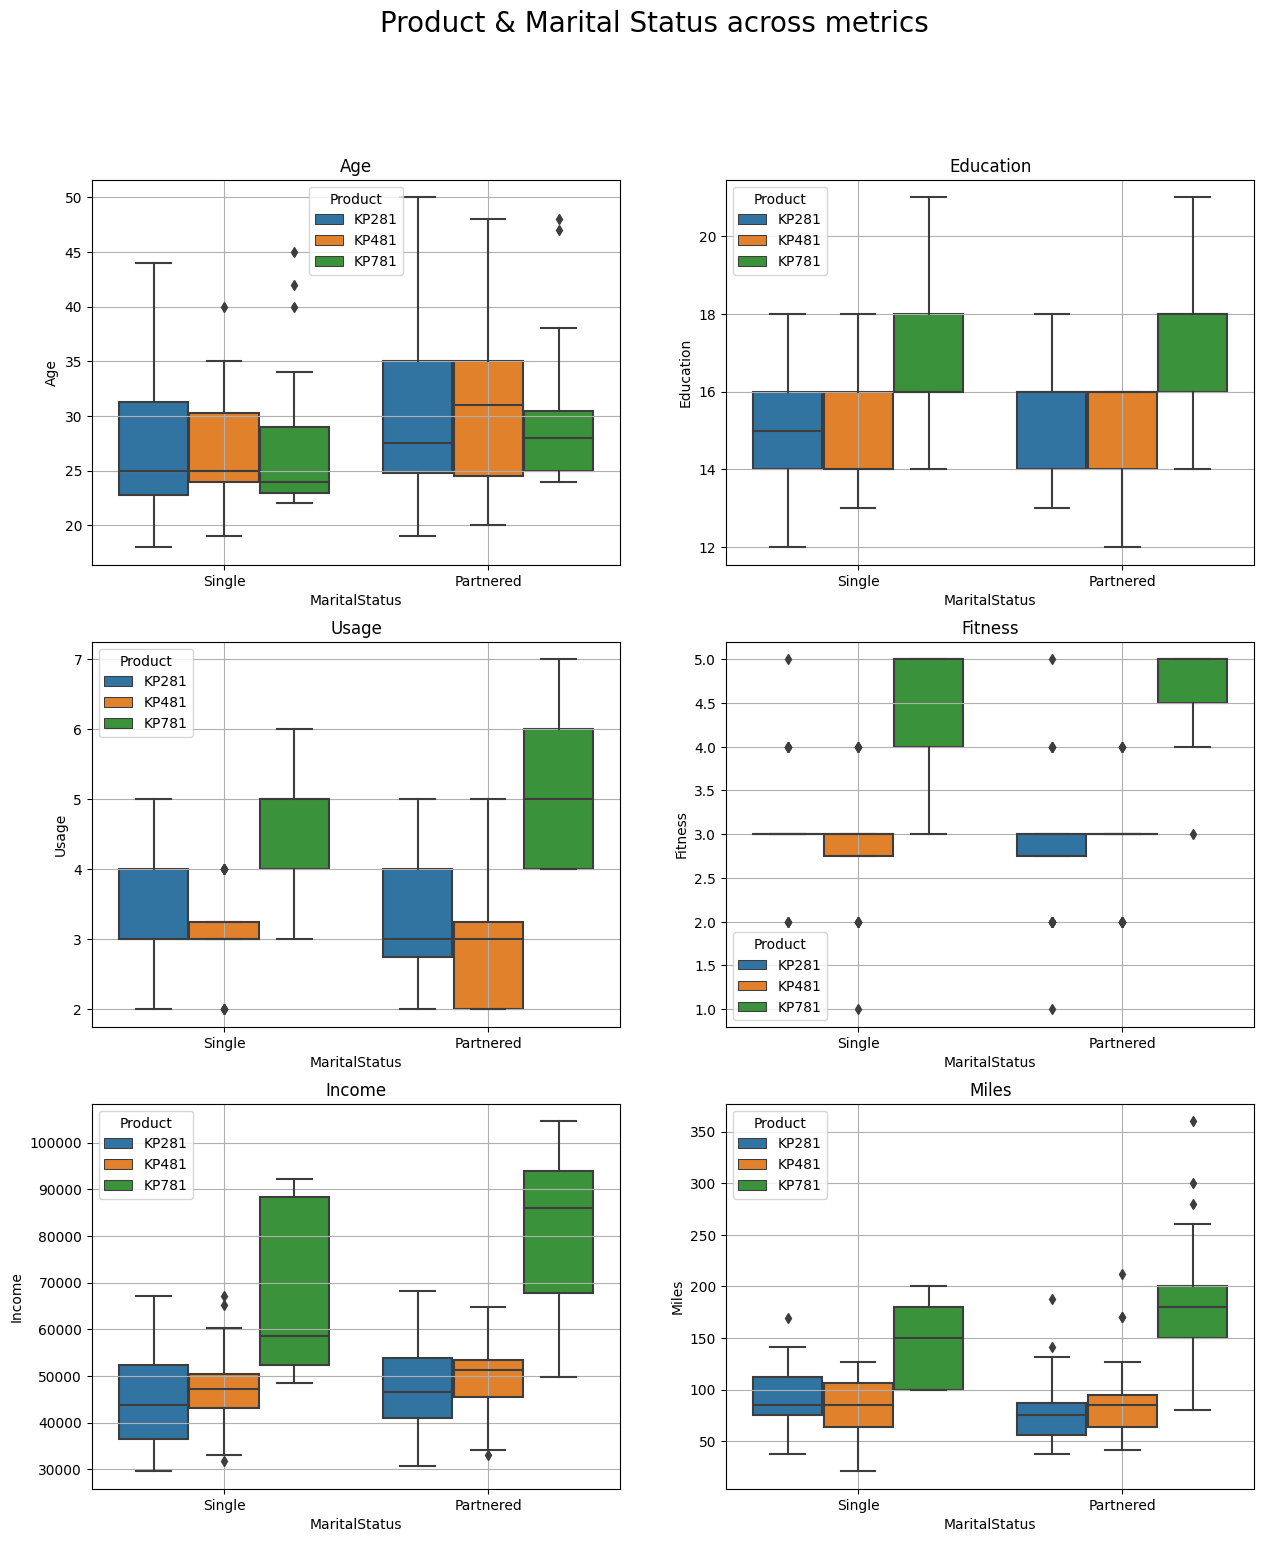

In [70]:
fig = plt.figure(figsize=(15,17))
fig.suptitle("Product & Marital Status across metrics", fontsize = 20)

plt.subplot(3,2,1)

sns.boxplot(data = aerofit, y = "Age", x = "MaritalStatus", hue = "Product")
plt.title("Age", fontsize = 12)
plt.grid()

plt.subplot(3,2,2)

sns.boxplot(data = aerofit, y = "Education", x = "MaritalStatus", hue = "Product")
plt.title("Education", fontsize = 12)
plt.grid()

plt.subplot(3,2,3)

sns.boxplot(data = aerofit, y = "Usage", x = "MaritalStatus", hue = "Product")
plt.title("Usage", fontsize = 12)
plt.grid()

plt.subplot(3,2,4)

sns.boxplot(data = aerofit, y = "Fitness", x = "MaritalStatus", hue = "Product")
plt.title("Fitness", fontsize = 12)
plt.grid()

plt.subplot(3,2,5)

sns.boxplot(data = aerofit, y = "Income", x = "MaritalStatus", hue = "Product")
plt.title("Income", fontsize = 12)
plt.grid()

plt.subplot(3,2,6)

sns.boxplot(data = aerofit, y = "Miles", x = "MaritalStatus", hue = "Product")
plt.title("Miles", fontsize = 12)
plt.grid()



plt.show()

## **Observations:**
1. **Product KP281 & KP481:**
  - Mostly preferred by Younger Singles (age <= 31) and Mature Partnered Individuals (age <= 35)
  - Most Singles and Partnered users have education <= 16.
  - Although for KP281 the min education for Partnered users is 13 compared to 12 for Singles
  - For KP481 the max education for Partnered users is 16 compared to 18 for Singles
  - KP481 has a lower usage compared to KP281 for both Singles and Partnered.
  - 75% of usage of KP281 for both Singles and Partnered is <= 4 times per week
  - Most of the Singles or Partnered users having income <= 51500 would choose either of the two products.
  - Although it is seen that for income <= 45000 the demand for both the products is higher for Singles whereas Partnered users mostly prefer KP281.
  - Singles looking to run miles >= 100 and <= 115 prefer either of the two products
  - Partnered users usually running lesser miles < 100 opt for either of the products
2. **Product KP781:**
  - Mostly caters to Singles in their 20s, few Partnered individuals have ages >= 30
  - Requires higher Education since for both Singles and Partnered most users have <= 18 years of Education. With a min of 14 and max of 21 excluding outliers.
  - Partnered users have higher usage than Single users:
    - 75% Partnered usage: 6 times a week
    - 75% Single usage: 5 times a week
  - Mostly prefered by users having better shape (fitness >= 4) across both Singles and Partners
    - Partnered users choosing KP781 generally have better shape than Singles since their min without outliers is 4.0. For Singles the min is 3.0.
  - 75 % of users with Income >= 69000 are Partnered users, whereas only a few Singles with income in that limit prefer KP781
  - 75 % of users with Miles run >= 150 are Partnered users whereas only 50 % of Singles within that range prefer KP781.


<Figure size 1200x800 with 0 Axes>

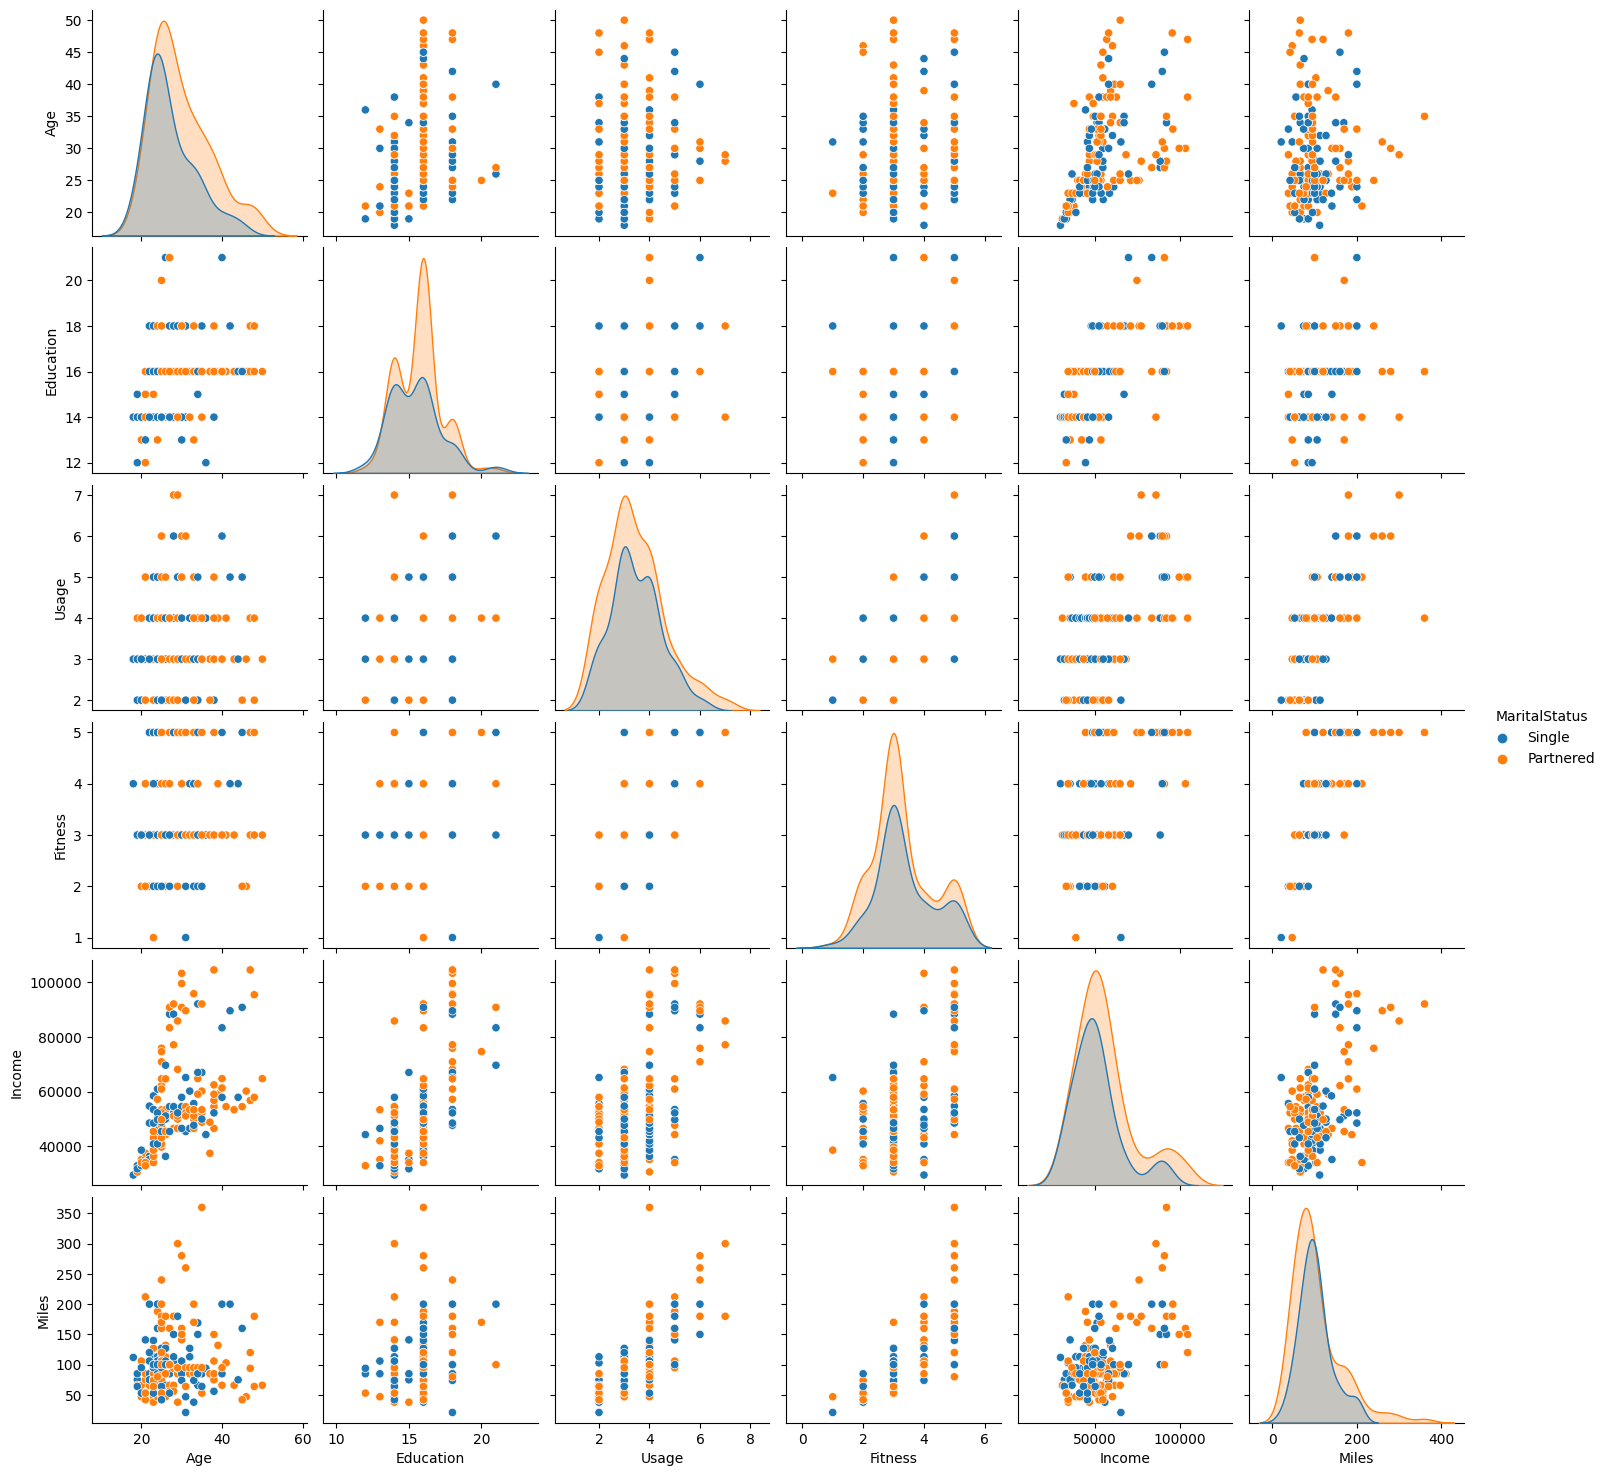

In [82]:
plt.figure(figsize=(12,8))
sns.pairplot(aerofit, hue = "MaritalStatus")
plt.show()

<Figure size 1200x800 with 0 Axes>

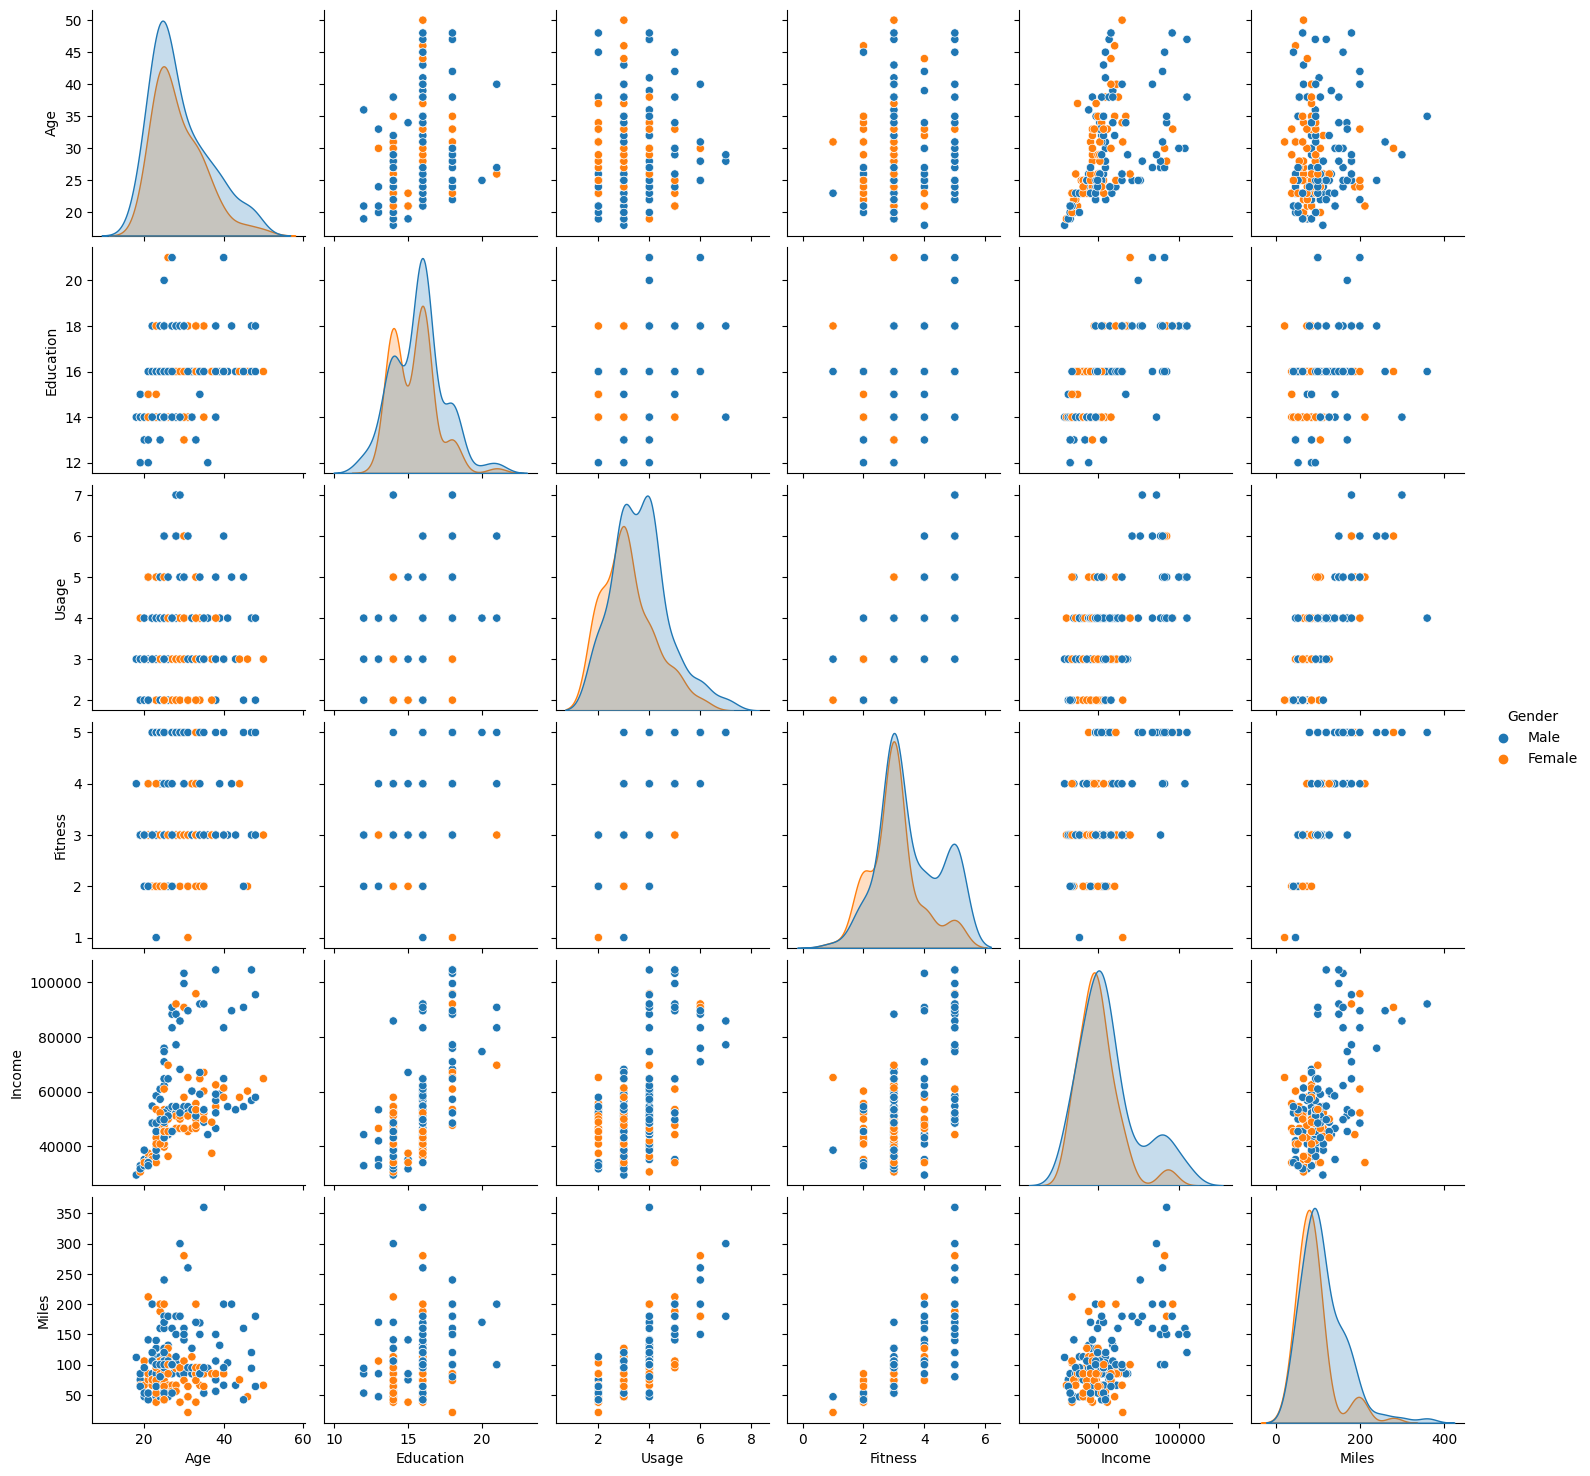

In [88]:
plt.figure(figsize=(12,8))
sns.pairplot(aerofit, hue = "Gender")
plt.show()

<Figure size 1200x800 with 0 Axes>

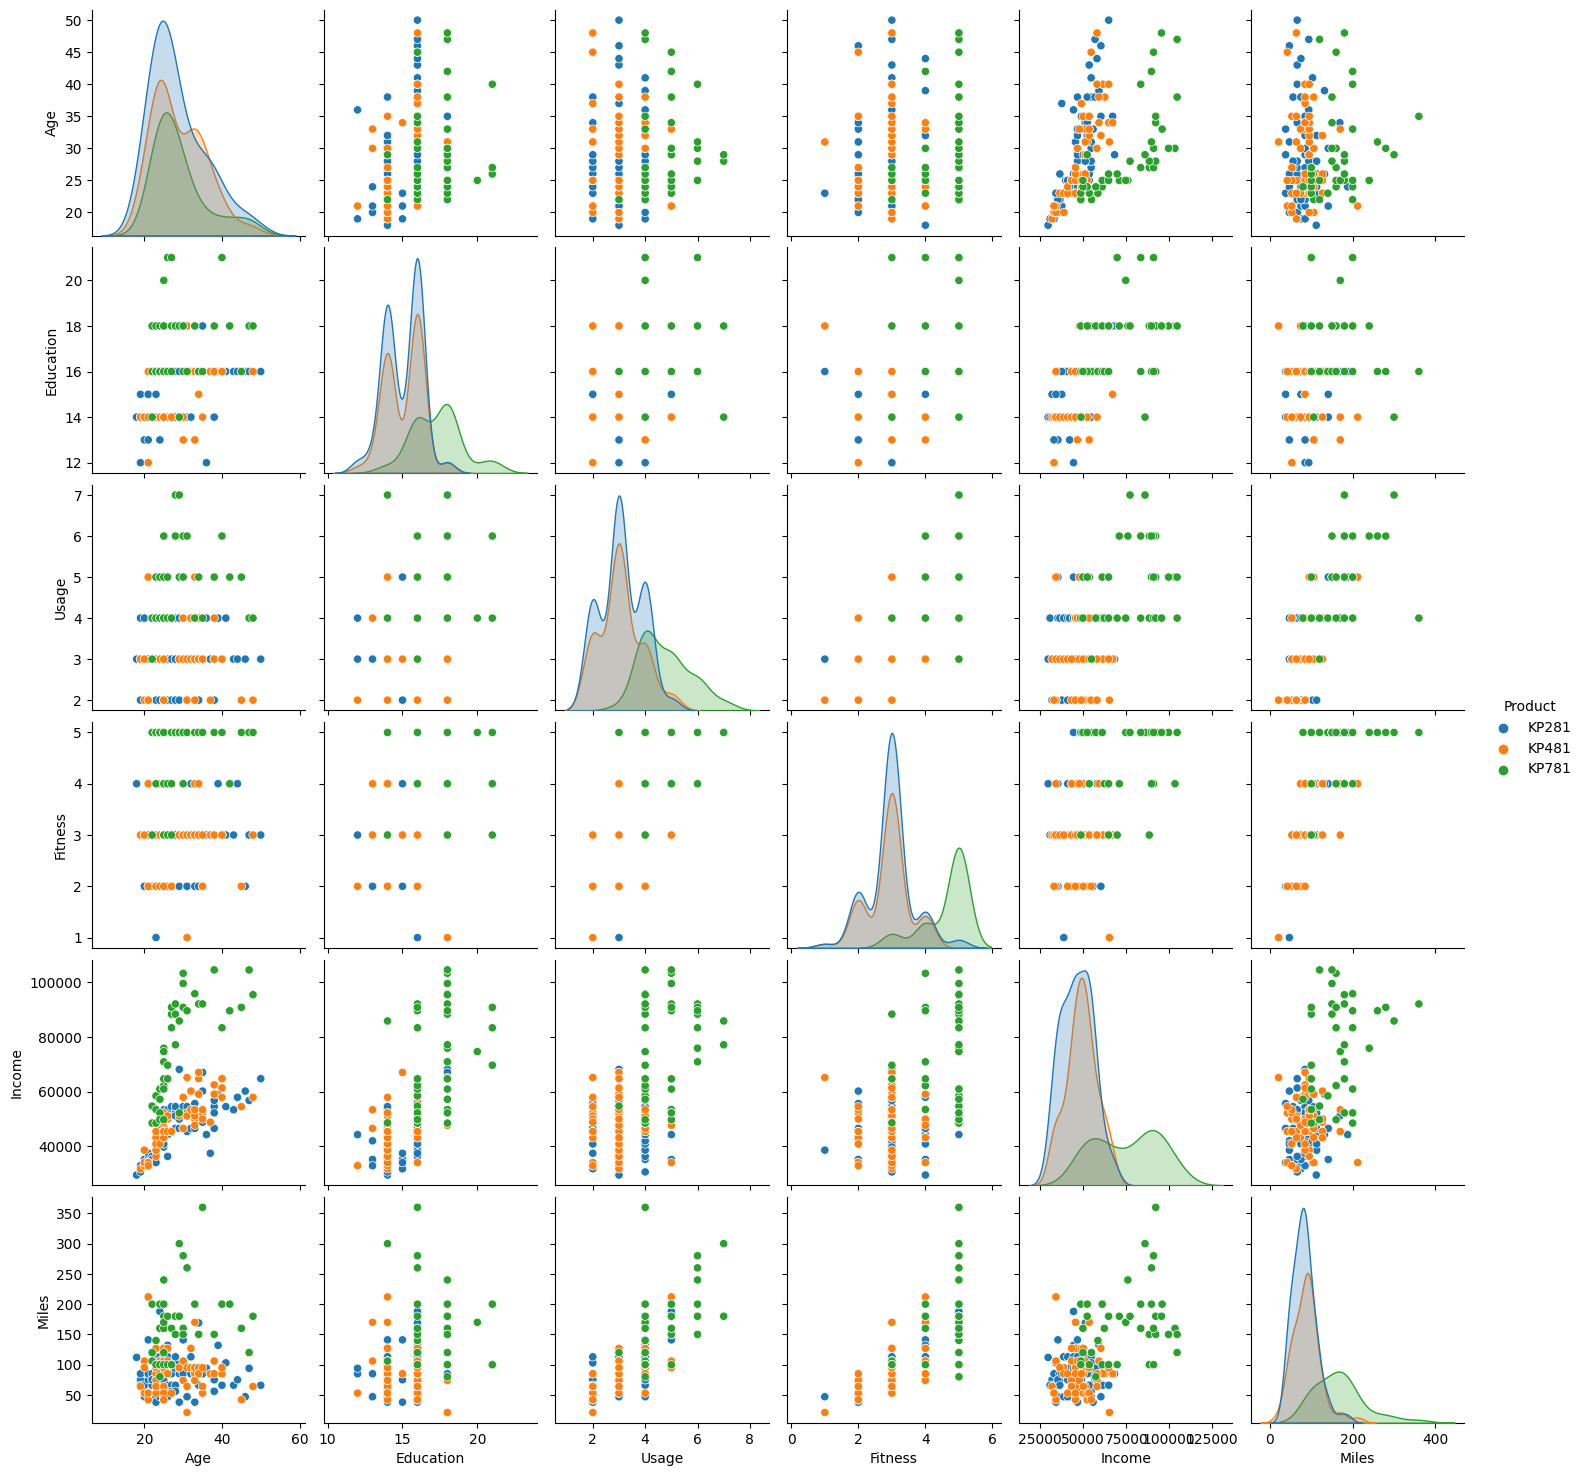

In [87]:
plt.figure(figsize=(12,8))
sns.pairplot(aerofit, hue = "Product")
plt.show()

## **Probability Analysis**

###**Marginal Probability**

In [73]:
aerofit["Product"].value_counts(normalize = True)

KP281    0.444444
KP481    0.333333
KP781    0.222222
Name: Product, dtype: float64

### **Conditional Probability**

In [74]:
df = pd.crosstab(index = aerofit["Gender"], columns = [aerofit["Product"]])
df

Product,KP281,KP481,KP781
Gender,,,
Female,40,29,7
Male,40,31,33


In [75]:
def product_prob_given_gender(gender):
  p781 = (df['KP781'][gender] / df.loc[gender].sum()).round(2)
  p481 = (df['KP481'][gender] / df.loc[gender].sum()).round(2)
  p281 = (df['KP281'][gender] / df.loc[gender].sum()).round(2)

  print(f"P(KP781/{gender}) : {p781}")
  print(f"P(KP481/{gender}) : {p481}")
  print(f"P(KP281/{gender}) : {p281} \n")

In [76]:
aerofit["Gender"].value_counts(normalize = True).round(2)

Male      0.58
Female    0.42
Name: Gender, dtype: float64

In [77]:
gender = aerofit["Gender"].unique()
for i in gender:
  product_prob_given_gender(i)

P(KP781/Male) : 0.32
P(KP481/Male) : 0.3
P(KP281/Male) : 0.38 

P(KP781/Female) : 0.09
P(KP481/Female) : 0.38
P(KP281/Female) : 0.53 



## **Observations:**
  1. **For KP781:** Males are more likely to purchase the product than Females
    - **Male users:** 32%
    - **Female users:** 9%
  2.  **For both KP481 and KP281:** Females are more likely to purchase the products than Males.
    - KP481:
        - **Male users:** 30%
        - **Female users:** 38%
    - KP281:
        - **Male users:** 38%
        - **Female users:** 53%

In [78]:
df1 = pd.crosstab(index = aerofit["MaritalStatus"], columns = [aerofit["Product"]])
df1

Product,KP281,KP481,KP781
MaritalStatus,,,
Partnered,48,36,23
Single,32,24,17


In [79]:
def product_prob_given_marital_status(marital_status):
  p781 = (df1['KP781'][marital_status] / df1.loc[marital_status].sum()).round(2)
  p481 = (df1['KP481'][marital_status] / df1.loc[marital_status].sum()).round(2)
  p281 = (df1['KP281'][marital_status] / df1.loc[marital_status].sum()).round(2)

  print(f"P(KP781/{marital_status}) : {p781}")
  print(f"P(KP481/{marital_status}) : {p481}")
  print(f"P(KP281/{marital_status}) : {p281} \n")

In [80]:
aerofit["MaritalStatus"].value_counts(normalize = True)

Partnered    0.594444
Single       0.405556
Name: MaritalStatus, dtype: float64

In [81]:
ms = aerofit["MaritalStatus"].unique()
for i in ms:
  product_prob_given_marital_status(i)

P(KP781/Single) : 0.23
P(KP481/Single) : 0.33
P(KP281/Single) : 0.44 

P(KP781/Partnered) : 0.21
P(KP481/Partnered) : 0.34
P(KP281/Partnered) : 0.45 



## **Observations:**
  1. **For KP781:** Singles are more likely to purchase the product than Partnered users
    - **Single:** 23%
    - **Partnered:** 21%
  2.  **For both KP481 and KP281:** Partnered are more likely to purchase the products than Singles.
    - KP481:
        - **Singles:** 33%
        - **Partnered:** 34%
    - KP281:
        - **Singles:** 44%
        - **Partnered:** 45%

# **Recommendations:**
**For KP781:**
  1. **Target customers should be Male Single users with attributes**:
    - Age: 23-29
    - Education: 14-18
    - Usage: 3-5
    - Fitness: 3-5
    - Income: 49000 - 91000
    - Miles: 100-200

**For KP481:**
  1. **Target customers should be Partnered Female users with attributes**:
    - Age: 20-33
    - Education: 13-16
    - Usage: 2-5
    - Fitness: 3
    - Income: 41000 - 62000
    - Miles: 50-
    
**For KP281:**
  1. **Target customers should be Partnered Female users with attributes**:
    - Age: 19-33
    - Education: 14-18
    - Usage: 2-4
    - Fitness: 2.7-3
    - Income: 31000 - 68000
    - Miles: 48-120


  